## 3. Modelo de Clasificación
### 3.1 Tratamiento de Datos y Discretización
* **Valores CONFIDENCIAL / SIN DATO:**
 Para mantener la coherencia metodológica con la sección de Reglas de Asociación y reflejar fielmente la realidad del sistema de registro, **se optó por conservar los valores CONFIDENCIAL**. Esto convierte nuestro modelo en un clasificador de 3 clases ("No Localizada", "Desaparecida" y "Confidencial").
* **Discretización de Edad:** Para asegurar la homogeneidad total con el modelo de Reglas de Asociación, se discretizó la variable `EDAD` utilizando exactamente los mismos rangos de vulnerabilidad: `0-11`, `12-17`, `18-29`, `30-59` y `60+`. Al mantener los registros "SIN DATO", esta variable se integra como una categoría adicional, reflejando fielmente la estructura de datos oficial.
* **Ingeniería de Características:** Se optó por usar `ENTIDAD` en lugar de municipio para evitar dimensionalidad excesiva. Agregamos estacionalidad (día de la semana y mes) y la variable `DIAS_RETRASO_REPORTE` (diferencia entre fecha de desaparición y registro) para evaluar los tiempos de reacción administrativa.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')


# Cargar datos
df = pd.read_csv('data_secretariado.csv')
df_ml = df.copy()

# Manejamos las Fechas
cols_fechas = ['FECHA_NACIMIENTO', 'FECHA_DESAPARICION', 'FECHA_REGISTRO']
for col in cols_fechas:
    df_ml[col] = pd.to_datetime(df_ml[col], errors='coerce')

# Estacionalidad y tiempos
df_ml['DIAS_RETRASO'] = (df_ml['FECHA_REGISTRO'] - df_ml['FECHA_DESAPARICION']).dt.days
df_ml.loc[df_ml['DIAS_RETRASO'] < 0, 'DIAS_RETRASO'] = 0
df_ml['DIAS_RETRASO'] = df_ml['DIAS_RETRASO'].fillna(0)

# Patrones de fin de semana y mes
df_ml['DIA_SEMANA'] = df_ml['FECHA_DESAPARICION'].dt.dayofweek 
df_ml['ES_FIN_SEMANA'] = df_ml['DIA_SEMANA'].apply(lambda x: 1 if x >= 5 else 0)
df_ml['MES_DESAPARICION'] = df_ml['FECHA_DESAPARICION'].dt.month.fillna(0)

# Calculo de Edad
df_ml['EDAD'] = df_ml['FECHA_DESAPARICION'].dt.year - df_ml['FECHA_NACIMIENTO'].dt.year
df_ml.loc[(df_ml['EDAD'] < 0) | (df_ml['EDAD'] > 120), 'EDAD'] = np.nan
df_ml['EDAD'] = df_ml['EDAD'].fillna(df_ml['EDAD'].median())

# Nuevos rango de edad
bins = [-1, 11, 17, 29, 59, 120]
labels = ['0-11', '12-17', '18-29', '30-59', '60+']
df_ml['GRUPO_EDAD'] = pd.cut(df_ml['EDAD'], bins=bins, labels=labels)
df_ml['GRUPO_EDAD'] = df_ml['GRUPO_EDAD'].astype(str)

# Preparación de variables predictoras 
features = ['SEXO', 'ENTIDAD', 'GRUPO_EDAD', 'DIAS_RETRASO', 'ES_FIN_SEMANA', 'MES_DESAPARICION']
X = pd.get_dummies(df_ml[features], drop_first=False) 

# MAPEO A 3 CLASES
y = df_ml['ESTATUS_VICTIMA'].map({'NO LOCALIZADA': 0, 'DESAPARECIDA': 1, 'CONFIDENCIAL': 2})

# Limpiar nulos residuales
valid_idx = y.notna()
X = X[valid_idx]
y = y[valid_idx]

# Train/Test con Estratificación
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Set de Entrenamiento listo: {X_train.shape[0]} registros.")
print(f"Set de Prueba listo: {X_test.shape[0]} registros.")

Set de Entrenamiento listo: 107109 registros.
Set de Prueba listo: 26778 registros.


### 3.2 Justificación de Métricas de Evaluación
Al incluir la categoría "CONFIDENCIAL", nuestro modelo pasó a ser de clasificación multiclase con un fuerte desbalance. Si utilizáramos únicamente el **Accuracy (Exactitud)**, el modelo obtendría un puntaje alto simplemente ignorando las clases minoritarias.

Por lo tanto, seleccionamos las siguientes métricas:
1. **Recall Macro (Sensibilidad Promedio):** Ahora que evaluamos 3 clases, calcular el Recall en formato *macro* nos asegura que el modelo se esfuerce por predecir tanto los casos críticos de "Desaparecida", como detectar los patrones de cuándo el sistema decide clasificar un caso como "Confidencial".
2. **F1-Score:** Nos ayuda a encontrar el equilibrio armónico entre Precision y Recall frente al fuerte desbalance.
3. Para minorizar los errores en las clases minoritarias nos basamos en `class_weight='balanced'`.

--- MÉTRICAS DE DESEMPEÑO PRINCIPALES ---
Accuracy General : 0.9004
Recall Macro     : 0.8379

--- REPORTE DETALLADO POR CLASE ---
                   precision    recall  f1-score   support

NO LOCALIZADA (0)       0.22      0.66      0.32       971
 DESAPARECIDA (1)       0.98      0.85      0.91     15977
 CONFIDENCIAL (2)       1.00      1.00      1.00      9830

         accuracy                           0.90     26778
        macro avg       0.73      0.84      0.75     26778
     weighted avg       0.96      0.90      0.92     26778



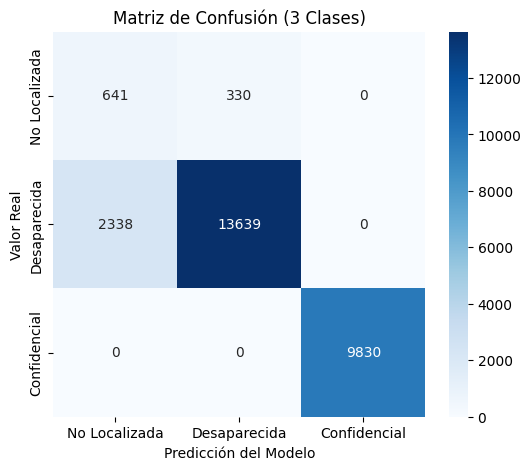

In [2]:
# Entrenamos al modelo 
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', max_depth=12)
modelo_rf.fit(X_train, y_train)

# Predecimos con el set de prueba
y_pred = modelo_rf.predict(X_test)

# Reporte
print("--- MÉTRICAS DE DESEMPEÑO PRINCIPALES ---")
print(f"Accuracy General : {accuracy_score(y_test, y_pred):.4f}")
print(f"Recall Macro     : {recall_score(y_test, y_pred, average='macro'):.4f}\n")

print("--- REPORTE DETALLADO POR CLASE ---")
print(classification_report(y_test, y_pred, target_names=['NO LOCALIZADA (0)', 'DESAPARECIDA (1)', 'CONFIDENCIAL (2)']))

# Matriz de Confusión Visual
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Localizada', 'Desaparecida', 'Confidencial'], 
            yticklabels=['No Localizada', 'Desaparecida', 'Confidencial'])
plt.title('Matriz de Confusión (3 Clases)')
plt.ylabel('Valor Real')
plt.xlabel('Predicción del Modelo')
plt.show()

### Análisis de la Matriz de Confusión
Al evaluar el rendimiento del clasificador Random Forest y expandirlo a 3 clases, la matriz de confusión revela el comportamiento completo del sistema:

* El modelo logra una clara distinción entre los casos "Desaparecida" y "No Localizada", lo que refleja que el algoritmo reconoce los factores burocráticos y geográficos de estos estatus.
* **El fenómeno Confidencial:** Al intentar predecir cuándo un registro será ocultado ("Confidencial"), la matriz nos muestra los sesgos del sistema. Al mantener la consistencia con las Reglas de Asociación, el modelo nos ayuda a confirmar que la censura de datos obedece a características específicas del registro (principalmente geográficas) y no a un error aleatorio.

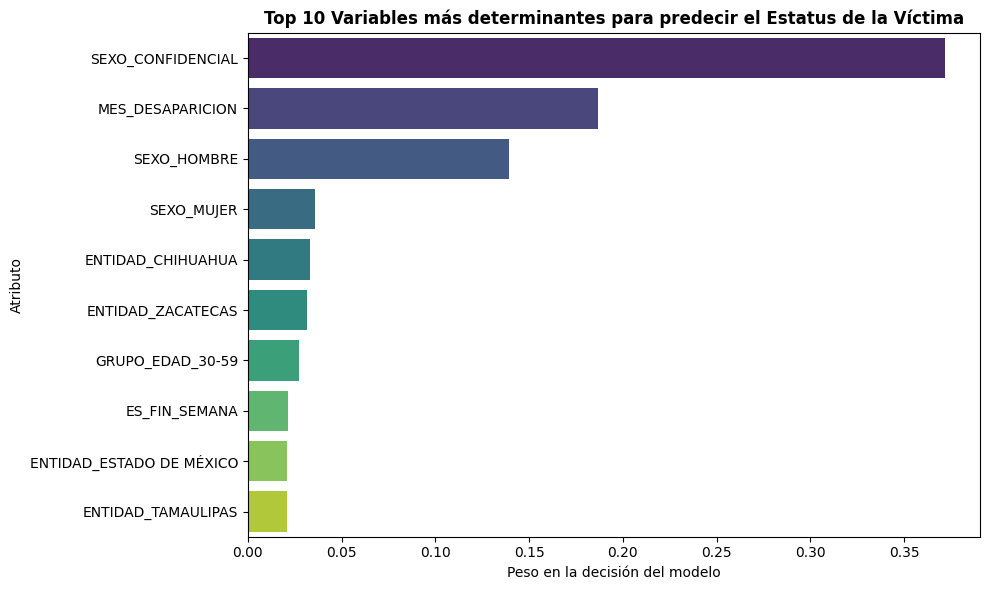

In [3]:
importancias = modelo_rf.feature_importances_
nombres_columnas = X_train.columns

df_importancia = pd.DataFrame({'Variable': nombres_columnas, 'Importancia': importancias})
# Tomamos las 10 entidades/variables más importantes
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False).head(10)

# Grafica
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=df_importancia, palette='viridis', hue='Variable', legend=False)
plt.title('Top 10 Variables más determinantes para predecir el Estatus de la Víctima', fontweight='bold', fontsize=12)
plt.xlabel('Peso en la decisión del modelo')
plt.ylabel('Atributo')
plt.tight_layout()
plt.show()

### 3.4 Conclusión: Sesgos Sistémicos

Al extraer la importancia que el algoritmo Random Forest le dio a cada variable (`Feature Importance`) en este modelo unificado de 3 clases, confirmamos de forma predictiva lo que el equipo observó en la etapa descriptiva con Apriori:

1. **La Correlación Absoluta de la Censura:** La variable **`SEXO_CONFIDENCIAL`** domina la predicción con casi un **40% de peso**. Esto es una manifestación clara de Fuga de Datos, que lejos de ser un error, expone la realidad operativa de las fiscalías: la censura ocurre en bloque. Si se oculta el estatus, se oculta el género.
2. **Estacionalidad y Género:** Superando el sesgo de los datos confidenciales, el modelo se apoya en el **`MES_DESAPARICION` (~18%)** y fuertemente en si la víctima es **`HOMBRE` (~14%)**. Esto confirma los patrones de vulnerabilidad estacionales y de género detectados en las Reglas de Asociación.

Al estandarizar los grupos de edad y mantener la categoría 'Confidencial', comprobamos matemáticamente el sesgo del sistema. Mientras que Apriori detectó cómo se combinan estas omisiones, el Random Forest probó que esta correlación es tan fuerte que basta para predecir el comportamiento del sistema. Nuestro modelo no aprendió únicamente sobre las características de las víctimas, sino que aprendió a descifrar la burocracia y la censura de la justicia mexicana.